# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


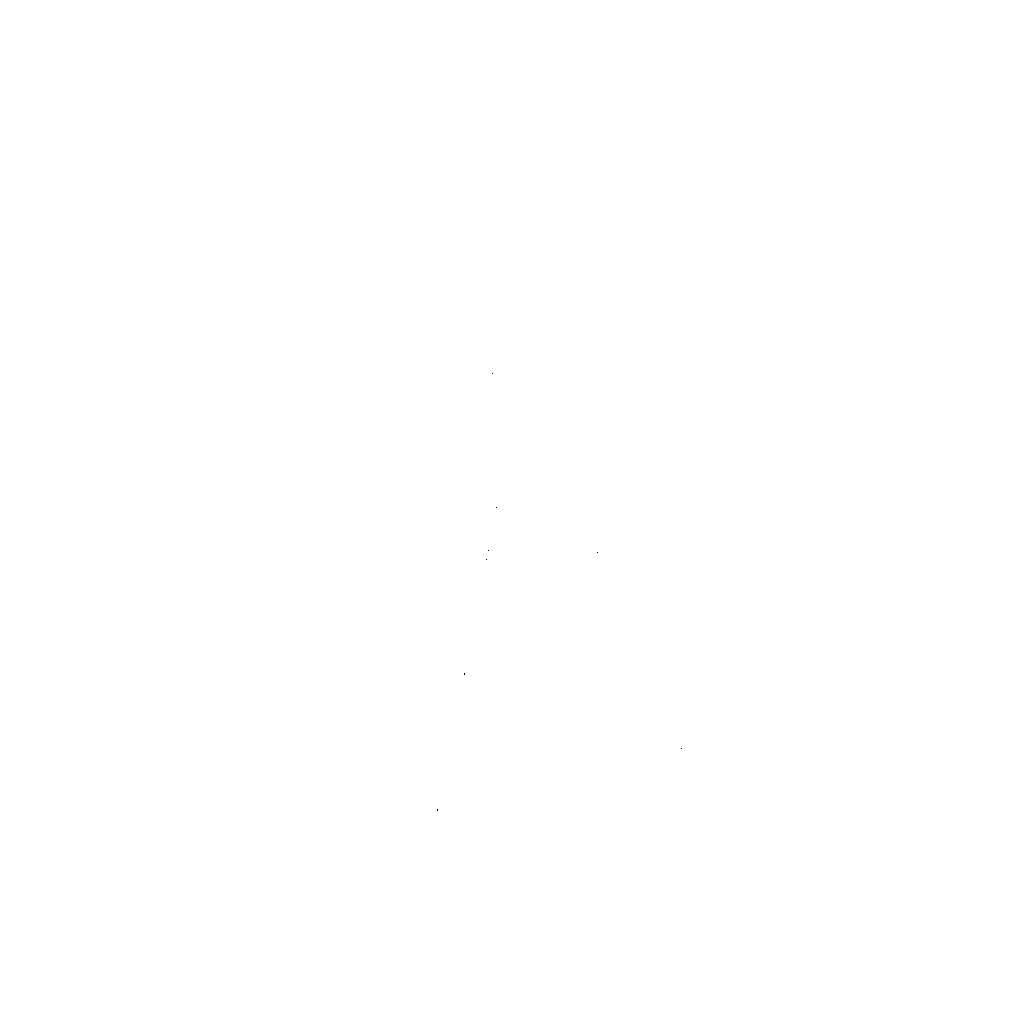

Threshold value: 50


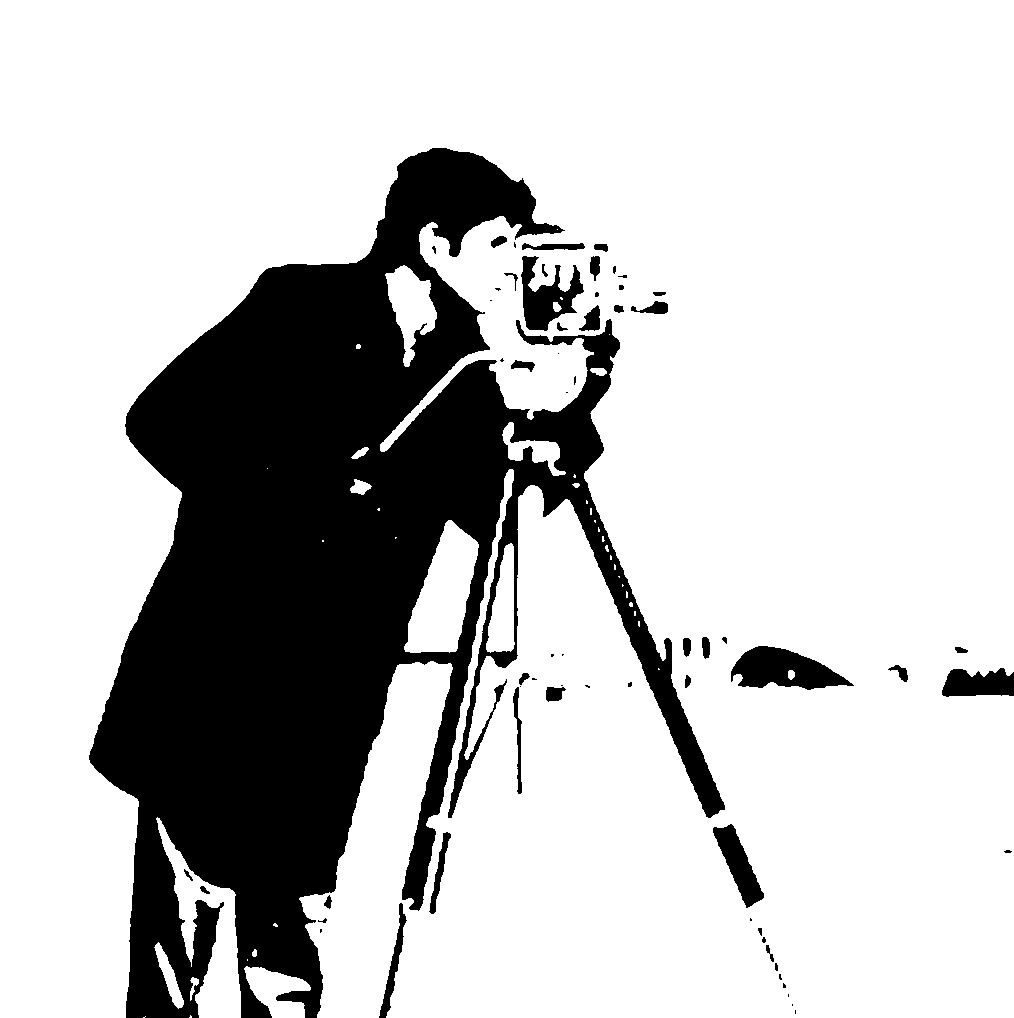

Threshold value: 100


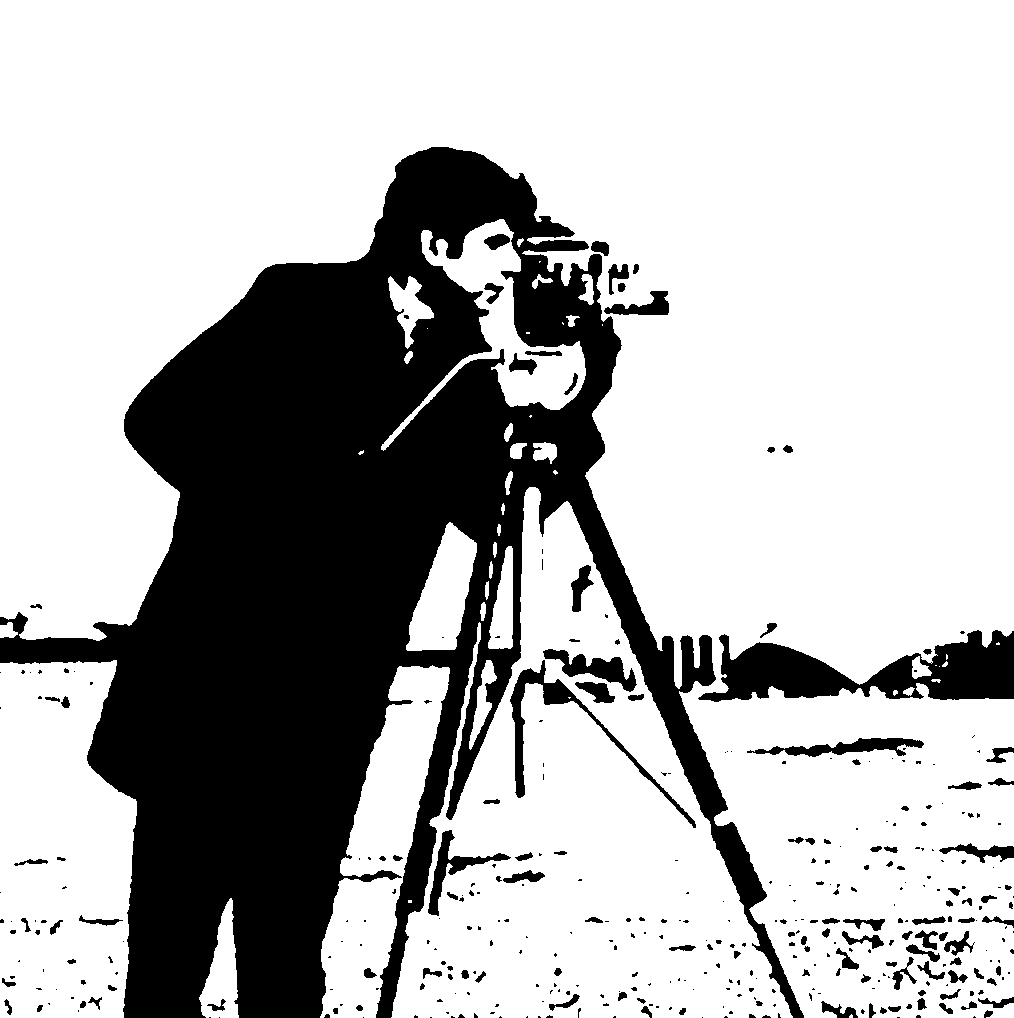

Threshold value: 150


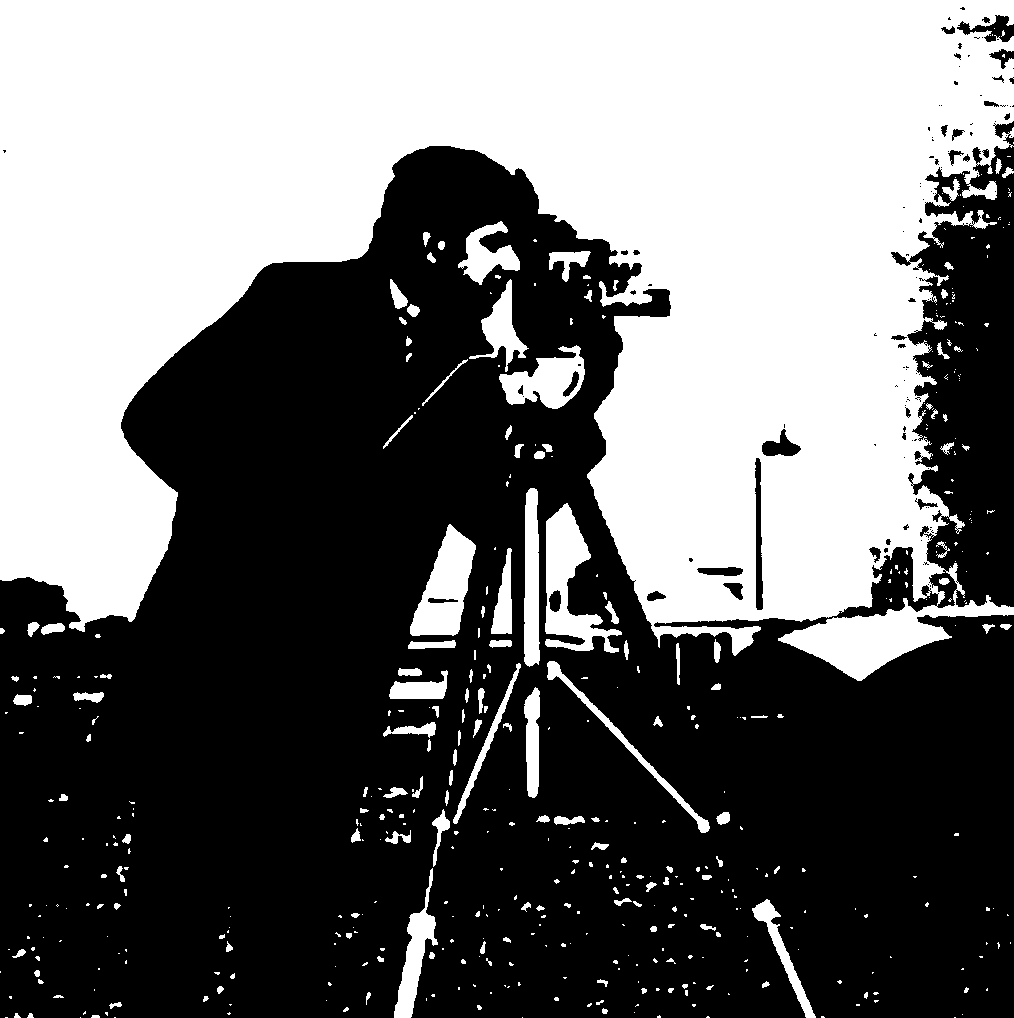

Threshold value: 200


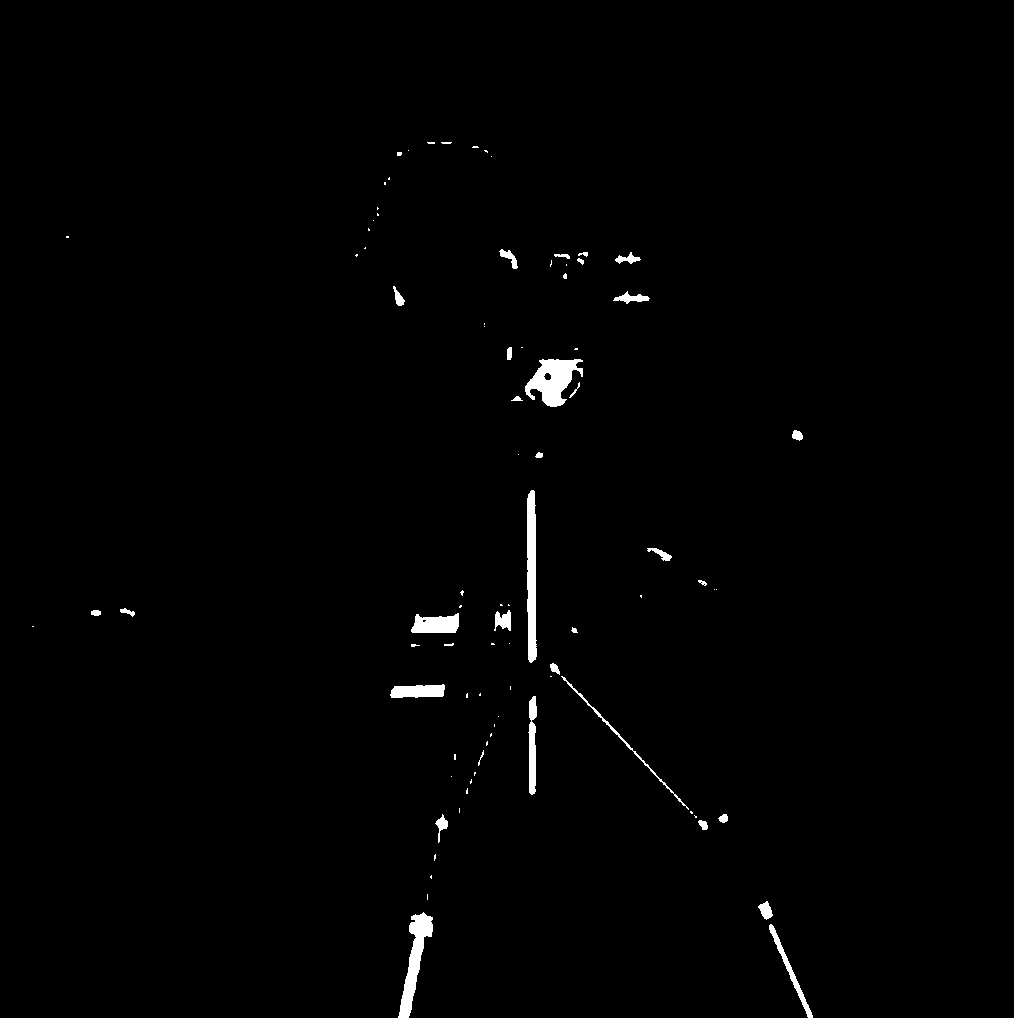

In [3]:
import os
import cv2
import matplotlib.pyplot as plt

try:
    from google.colab.patches import cv2_imshow
except ImportError:
    def cv2_imshow(image):
        plt.figure(figsize=(5, 5))
        plt.imshow(image, cmap='gray')
        plt.axis('off')
        plt.show()

# Load the image in grayscale. The extra paths make it work in Colab and locally.
image_paths = [
    'cameraman.png',
    '/content/cameraman.png',
    'upload/cameraman.png',
    '/workspace/scratch/c58882efb282/upload/cameraman.png'
]

img = None
for image_path in image_paths:
    if os.path.exists(image_path):
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        break

if img is None:
    raise FileNotFoundError('cameraman.png was not found. Upload it beside this notebook or to /content in Colab.')

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)

    print(f"Threshold value: {threshold_value}")
    cv2_imshow(thresh_img)


Original Image: 


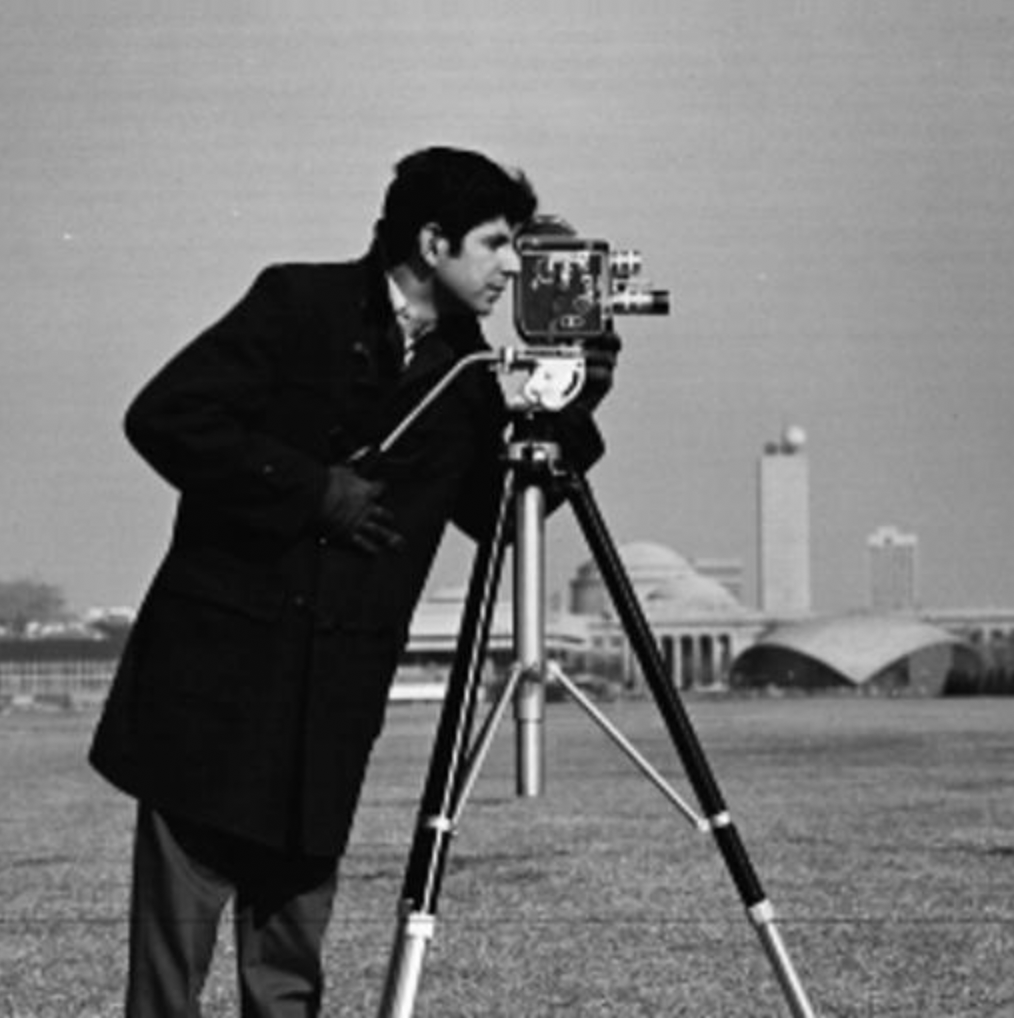

In [4]:
print("Original Image: ")
cv2_imshow(img)

## Histograms

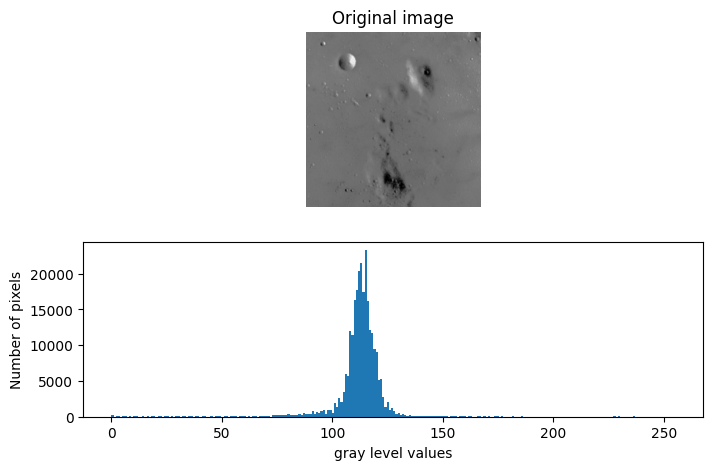

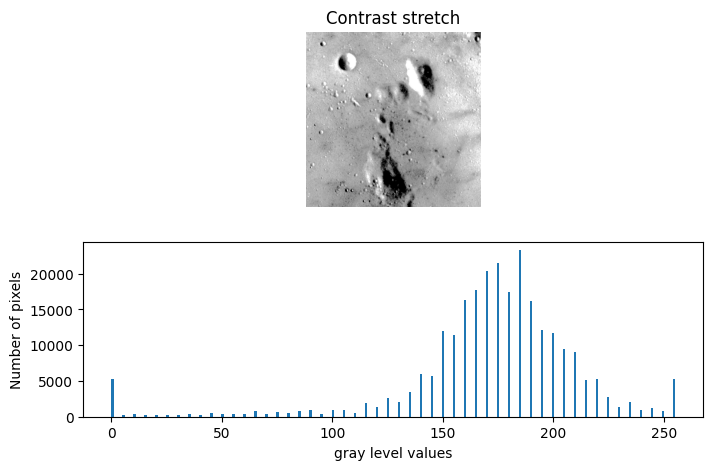

In [5]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


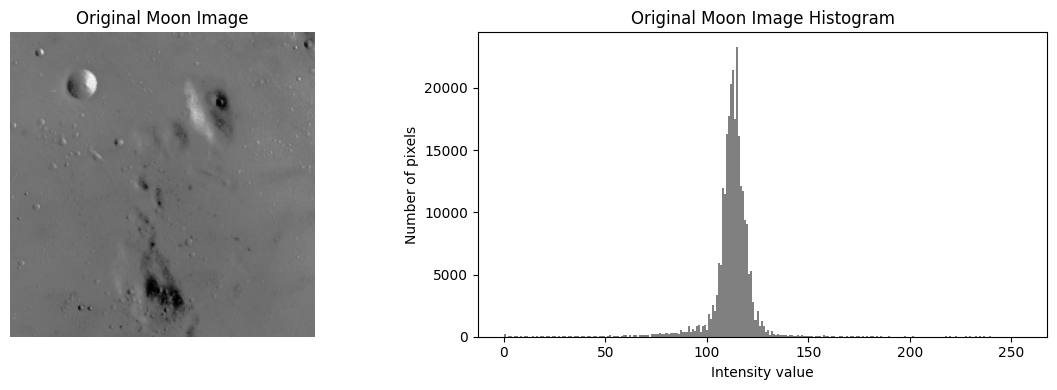

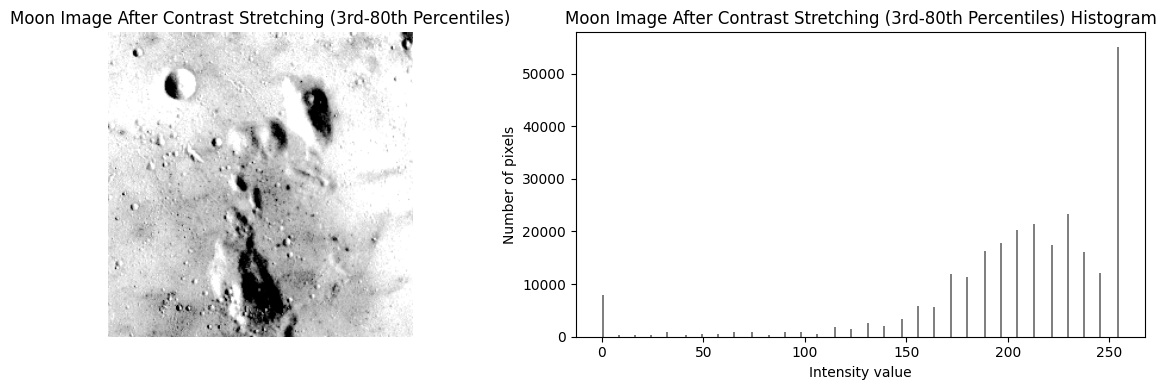

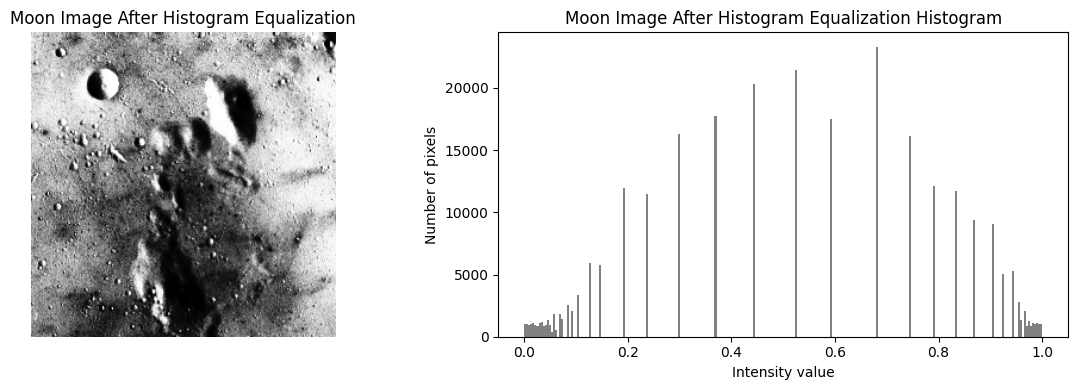

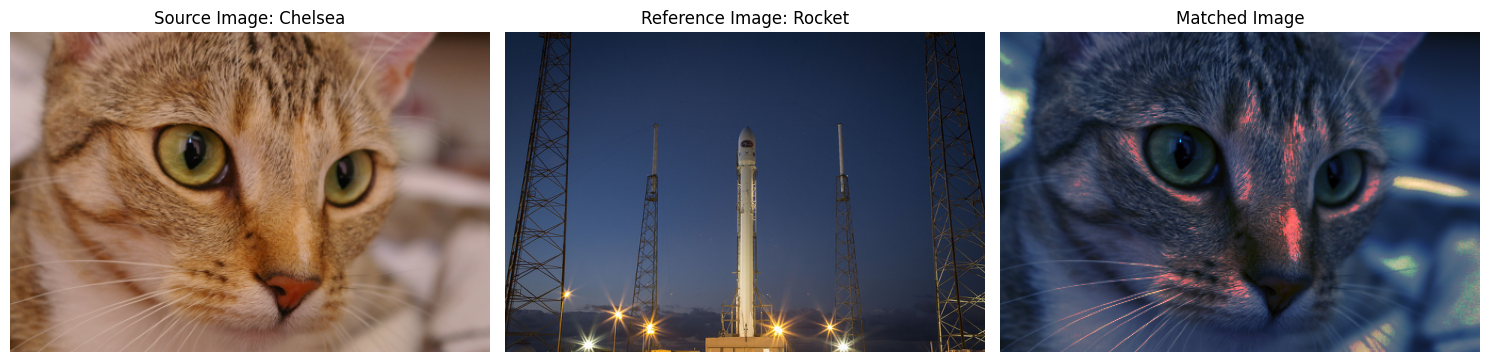

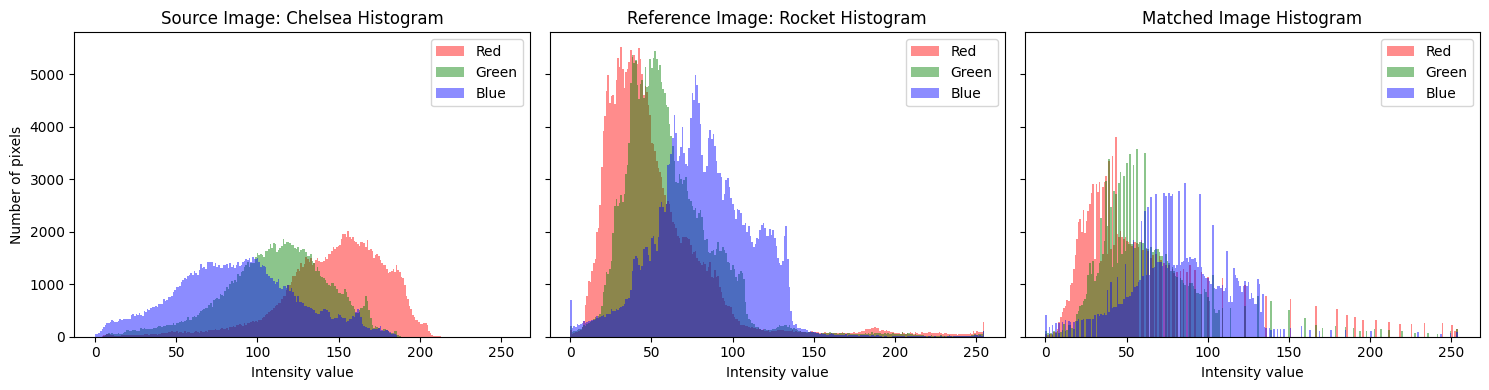

In [6]:
# Solutions for Tasks 1, 2, and 3
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure
from skimage.exposure import match_histograms


def show_gray_with_hist(image, title, hist_range=None):
    """Display a grayscale image and its histogram."""
    if hist_range is None:
        hist_range = (0, 1) if image.max() <= 1 else (0, 255)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title(title)
    axes[0].axis('off')

    axes[1].hist(image.ravel(), bins=256, range=hist_range, color='gray')
    axes[1].set_title(f'{title} Histogram')
    axes[1].set_xlabel('Intensity value')
    axes[1].set_ylabel('Number of pixels')
    plt.tight_layout()
    plt.show()


# Task 1: Contrast stretching using the 3rd and 80th percentiles
moon = data.moon()
p3, p80 = np.percentile(moon, (3, 80))
moon_rescale_3_80 = exposure.rescale_intensity(moon, in_range=(p3, p80))

show_gray_with_hist(moon, 'Original Moon Image', hist_range=(0, 255))
show_gray_with_hist(moon_rescale_3_80, 'Moon Image After Contrast Stretching (3rd-80th Percentiles)', hist_range=(0, 255))


# Task 2: Histogram equalization using exposure.equalize_hist
moon_equalized = exposure.equalize_hist(moon)

show_gray_with_hist(moon_equalized, 'Moon Image After Histogram Equalization', hist_range=(0, 1))


# Task 3: Histogram matching using rocket as the reference and chelsea as the source image
reference = data.rocket()
chelsea = data.chelsea()
matched = match_histograms(chelsea, reference, channel_axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
images = [chelsea, reference, matched]
titles = ['Source Image: Chelsea', 'Reference Image: Rocket', 'Matched Image']

for ax, image, title in zip(axes, images, titles):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()


# Plot RGB histograms to compare the source, reference, and matched images
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors = ['red', 'green', 'blue']

for ax, image, title in zip(axes, images, titles):
    for channel, color in enumerate(colors):
        ax.hist(image[..., channel].ravel(), bins=256, range=(0, 255), color=color, alpha=0.45, label=color.capitalize())
    ax.set_title(f'{title} Histogram')
    ax.set_xlabel('Intensity value')
    ax.legend()

axes[0].set_ylabel('Number of pixels')
plt.tight_layout()
plt.show()
